# 06. CatBoost (Categorical Boosting)

В этом ноутбуке:
- загрузка обработанных данных
- обучение базовой модели CatBoost с учётом дисбаланса (`auto_class_weights='Balanced'`)
- подбор гиперпараметров с помощью RandomizedSearchCV (с early stopping)
- оценка качества на валидационной выборке
- подбор порога классификации по F1-мере
- построение матрицы ошибок, ROC-кривой и графика важности признаков
- сохранение модели, метрик и графиков

### 1. Загрузка данных

In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
import os

# Создаём папку для графиков этой модели
FIGURES_DIR = '../reports/figures/06_catboost'
os.makedirs(FIGURES_DIR, exist_ok=True)

# Загрузка обработанных данных
X_train = np.load('../data/processed/X_train_scaled.npy')
X_val = np.load('../data/processed/X_val_scaled.npy')
y_train = np.load('../data/processed/y_train.npy')
y_val = np.load('../data/processed/y_val.npy')

feature_names = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse',
                 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
                 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
                 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

print(f"Размер обучающей выборки: {X_train.shape[0]} строк")
print(f"Размер валидационной выборки: {X_val.shape[0]} строк")
print(f"Доля дефолтов в обучающей выборке: {y_train.mean():.4f}")
print(f"Доля дефолтов в валидационной выборке: {y_val.mean():.4f}")

Размер обучающей выборки: 119773 строк
Размер валидационной выборки: 29944 строк
Доля дефолтов в обучающей выборке: 0.0660
Доля дефолтов в валидационной выборке: 0.0660


### 2. Обучение базовой модели CatBoost

In [2]:
# Для учёта дисбаланса используем auto_class_weights='Balanced'
cat_base = CatBoostClassifier(
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=False,
    eval_metric='AUC'
)
cat_base.fit(X_train, y_train)
print("Базовая модель CatBoost обучена")

Базовая модель CatBoost обучена


### 3. Оценка качества базовой модели

Precision: 0.2263
Recall:    0.6979
F1-score:  0.3418
ROC-AUC:   0.8527


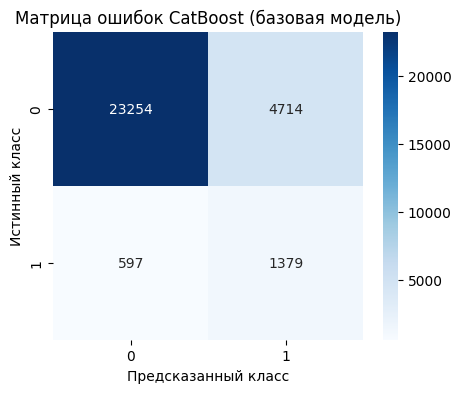

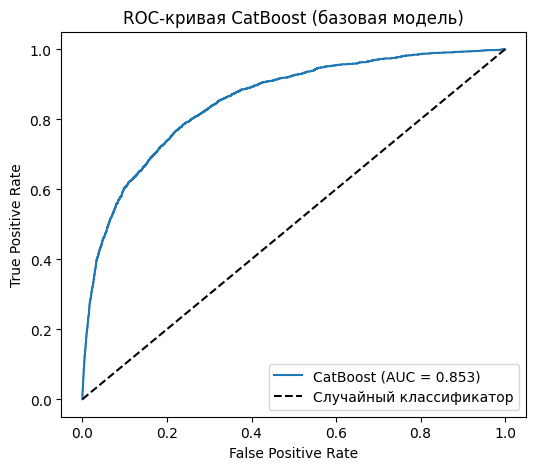

In [3]:
y_pred = cat_base.predict(X_val)
y_pred_proba = cat_base.predict_proba(X_val)[:, 1]

precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_pred_proba)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# Матрица ошибок
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок CatBoost (базовая модель)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.savefig(os.path.join(FIGURES_DIR, 'cat_confusion_matrix_base.png'), bbox_inches='tight')
plt.show()

# ROC-кривая
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'CatBoost (AUC = {roc_auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая CatBoost (базовая модель)')
plt.legend()
plt.savefig(os.path.join(FIGURES_DIR, 'cat_roc_curve_base.png'), bbox_inches='tight')
plt.show()

### 4. Подбор гиперпараметров (RandomizedSearchCV)

- Для ускорения используем случайный поиск по сетке параметров.
- Добавляем early stopping для автоматического определения оптимального числа деревьев.

In [4]:
param_dist = {
    'iterations': [100, 200, 300, 500],
    'depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bylevel': [0.7, 0.8, 0.9, 1.0],
    'l2_leaf_reg': [1, 3, 5, 7],
    'border_count': [32, 64, 128]
}

cat_tune = CatBoostClassifier(
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=False,
    eval_metric='AUC',
    early_stopping_rounds=10
)

random_search = RandomizedSearchCV(
    cat_tune, param_dist, n_iter=30, cv=3, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)

# Для early stopping передаём eval_set
random_search.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"Лучшие параметры: {random_search.best_params_}")
print(f"Лучший ROC-AUC на кросс-валидации: {random_search.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Лучшие параметры: {'subsample': 0.9, 'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 200, 'depth': 7, 'colsample_bylevel': 0.8, 'border_count': 64}
Лучший ROC-AUC на кросс-валидации: 0.8637


### 5. Оценка модели с лучшими гиперпараметрами

Метрики оптимизированной модели:
Precision: 0.2125
Recall:    0.7687
F1-score:  0.3329
ROC-AUC:   0.8649


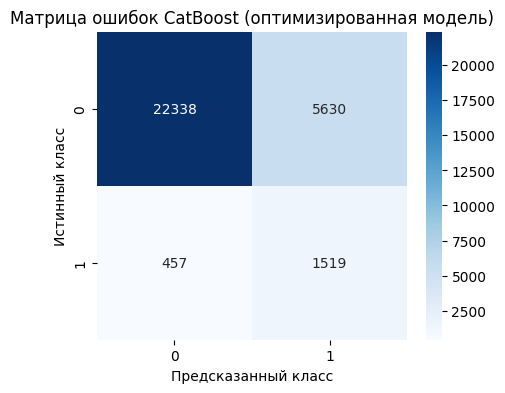

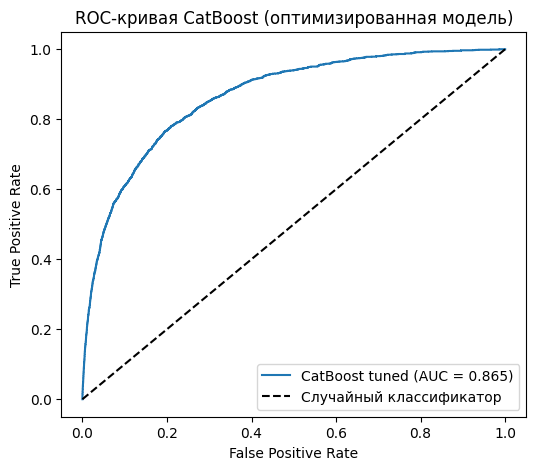

Порог 0.3: FP = 10471, FN = 204, потери = 1251


In [5]:
best_cat = random_search.best_estimator_
y_pred_best = best_cat.predict(X_val)
y_pred_proba_best = best_cat.predict_proba(X_val)[:, 1]

precision_best = precision_score(y_val, y_pred_best)
recall_best = recall_score(y_val, y_pred_best)
f1_best = f1_score(y_val, y_pred_best)
roc_auc_best = roc_auc_score(y_val, y_pred_proba_best)

print(f"Метрики оптимизированной модели:")
print(f"Precision: {precision_best:.4f}")
print(f"Recall:    {recall_best:.4f}")
print(f"F1-score:  {f1_best:.4f}")
print(f"ROC-AUC:   {roc_auc_best:.4f}")

# Матрица ошибок
cm_best = confusion_matrix(y_val, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок CatBoost (оптимизированная модель)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.savefig(os.path.join(FIGURES_DIR, 'cat_confusion_matrix_tuned.png'), bbox_inches='tight')
plt.show()

# ROC-кривая
fpr_best, tpr_best, _ = roc_curve(y_val, y_pred_proba_best)
roc_auc_best_val = auc(fpr_best, tpr_best)

plt.figure(figsize=(6,5))
plt.plot(fpr_best, tpr_best, label=f'CatBoost tuned (AUC = {roc_auc_best_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая CatBoost (оптимизированная модель)')
plt.legend()
plt.savefig(os.path.join(FIGURES_DIR, 'cat_roc_curve_tuned.png'), bbox_inches='tight')
plt.show()

# Экономическая оценка: расчёт для порога 0.3 (опционально)
threshold_03 = 0.3
y_pred_03 = (y_pred_proba_best >= threshold_03).astype(int)
tn_03, fp_03, fn_03, tp_03 = confusion_matrix(y_val, y_pred_03).ravel()
C_FN = 1.0
C_FP = 0.1
cost_03 = C_FP * fp_03 + C_FN * fn_03
print(f"Порог 0.3: FP = {fp_03}, FN = {fn_03}, потери = {cost_03:.0f}")

### 6. Визуализация важности признаков

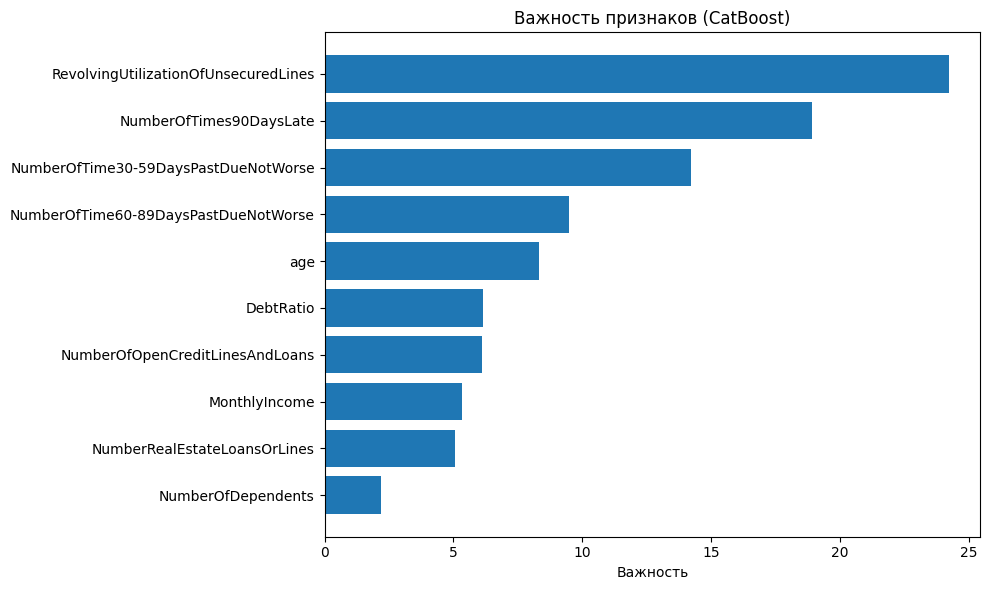

In [6]:
# CatBoost имеет встроенную функцию для важности признаков
feature_importance = best_cat.get_feature_importance()
sorted_idx = np.argsort(feature_importance)[::-1][:10]

plt.figure(figsize=(10, 6))
plt.barh(range(10), feature_importance[sorted_idx][::-1])
plt.yticks(range(10), [feature_names[i] for i in sorted_idx[::-1]])
plt.xlabel('Важность')
plt.title('Важность признаков (CatBoost)')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'cat_feature_importance.png'), bbox_inches='tight')
plt.show()

### 7. Подбор порога классификации по F1-мере (для оптимизированной модели)

Лучший порог: 0.780
F1-score при этом пороге: 0.4364
После подбора порога (best=0.780):
Precision: 0.3964
Recall:    0.4853
F1-score:  0.4364


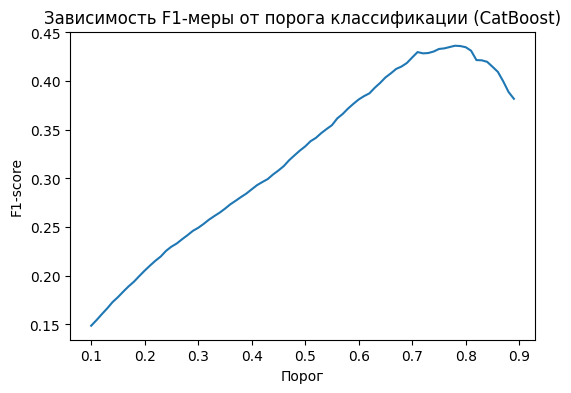

In [7]:
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_val, y_pred_proba_best >= t) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"Лучший порог: {best_threshold:.3f}")
print(f"F1-score при этом пороге: {best_f1:.4f}")

# Применяем новый порог
y_pred_adj = (y_pred_proba_best >= best_threshold).astype(int)
precision_adj = precision_score(y_val, y_pred_adj)
recall_adj = recall_score(y_val, y_pred_adj)
f1_adj = f1_score(y_val, y_pred_adj)

print(f"После подбора порога (best={best_threshold:.3f}):")
print(f"Precision: {precision_adj:.4f}")
print(f"Recall:    {recall_adj:.4f}")
print(f"F1-score:  {f1_adj:.4f}")

# График зависимости F1 от порога
plt.figure(figsize=(6,4))
plt.plot(thresholds, f1_scores)
plt.xlabel('Порог')
plt.ylabel('F1-score')
plt.title('Зависимость F1-меры от порога классификации (CatBoost)')
plt.savefig(os.path.join(FIGURES_DIR, 'cat_f1_threshold.png'), bbox_inches='tight')
plt.show()

### 8. Вывод: сравнение базовой и оптимизированной моделей

In [8]:
print("Сравнение базовой и оптимизированной модели CatBoost:")
print(f"Базовая:      Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, AUC={roc_auc:.4f}")
print(f"Оптимизированная: Precision={precision_best:.4f}, Recall={recall_best:.4f}, F1={f1_best:.4f}, AUC={roc_auc_best:.4f}")

# Если улучшение есть, выбираем оптимизированную модель, иначе базовую
if roc_auc_best > roc_auc:
    cat_final = best_cat
    print("Финальная модель: оптимизированная (RandomizedSearchCV)")
else:
    cat_final = cat_base
    print("Финальная модель: базовая (улучшения нет)")

Сравнение базовой и оптимизированной модели CatBoost:
Базовая:      Precision=0.2263, Recall=0.6979, F1=0.3418, AUC=0.8527
Оптимизированная: Precision=0.2125, Recall=0.7687, F1=0.3329, AUC=0.8649
Финальная модель: оптимизированная (RandomizedSearchCV)


### 9. Сохранение модели, метрик и графиков

In [9]:
model_dir = '../models'
os.makedirs(model_dir, exist_ok=True)

# Сохраняем финальную модель
with open(os.path.join(model_dir, 'catboost.pkl'), 'wb') as f:
    pickle.dump(cat_final, f)

# Сохраняем метрики в текстовый файл
with open(os.path.join(FIGURES_DIR, 'metrics.txt'), 'w', encoding='utf-8') as f:
    f.write("=== Базовые метрики ===\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall:    {recall:.4f}\n")
    f.write(f"F1-score:  {f1:.4f}\n")
    f.write(f"ROC-AUC:   {roc_auc:.4f}\n\n")
    
    f.write("=== Оптимизированная модель (RandomizedSearchCV) ===\n")
    f.write(f"Лучшие параметры: {random_search.best_params_}\n")
    f.write(f"Precision: {precision_best:.4f}\n")
    f.write(f"Recall:    {recall_best:.4f}\n")
    f.write(f"F1-score:  {f1_best:.4f}\n")
    f.write(f"ROC-AUC:   {roc_auc_best:.4f}\n\n")
    
    f.write("=== Подбор порога (по F1) ===\n")
    f.write(f"Лучший порог: {best_threshold:.3f}\n")
    f.write(f"Precision при лучшем пороге: {precision_adj:.4f}\n")
    f.write(f"Recall при лучшем пороге:    {recall_adj:.4f}\n")
    f.write(f"F1 при лучшем пороге:        {f1_adj:.4f}\n")

print("Модель и метрики сохранены")

Модель и метрики сохранены
